Importar librerias 

In [1]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
Cargar el dataset

In [2]:

df = pd.read_csv("usuarios_win_mac_lin.csv")
df.head()


,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


Exploración Basica de los datos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB


In [4]:
df.describe()

,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000


Separamos las variables de entrada y salida

In [8]:
X = df.drop("clase", axis=1)
y = df["clase"]

Se divide en conjunto de entrenamiento y prueba

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

Normalizamos los datos

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Entrenamos el modelo de Regresión Logistica

In [11]:
modelo = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000
)

modelo.fit(X_train_scaled, y_train)

C:\Users\bvillalba\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


Realizamos las predicciones

In [12]:
y_pred = modelo.predict(X_test_scaled)

Evaluación del modelo
Exactitud

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo: {accuracy:.2f}")

Accuracy del modelo: 0.72


In [ ]:
Matriz de confusión

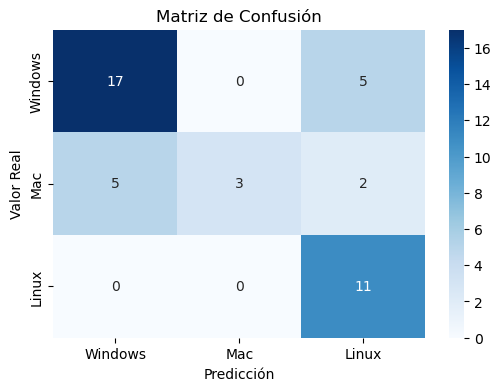

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Windows", "Mac", "Linux"],
            yticklabels=["Windows", "Mac", "Linux"])
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión")
plt.show()

In [ ]:
Reporte de Clasificación

In [16]:
print(classification_report(
    y_test, y_pred,
    target_names=["Windows", "Macintosh", "Linux"]
))

              precision    recall  f1-score   support

     Windows       0.77      0.77      0.77        22
   Macintosh       1.00      0.30      0.46        10
       Linux       0.61      1.00      0.76        11

    accuracy                           0.72        43
   macro avg       0.79      0.69      0.66        43
weighted avg       0.78      0.72      0.70        43



In [ ]:
Probamos el modelo con un nuevo usuario

In [18]:
nuevo_usuario = pd.DataFrame(
    [[300, 8, 25, 120]],
    columns=X.columns
)

nuevo_usuario_scaled = scaler.transform(nuevo_usuario)
prediccion = modelo.predict(nuevo_usuario_scaled)

prediccion


array([0])